# Analyse Exploratoire Approfondie (EDA) - Détection de Fraude Bitcoin
##Dataset: Elliptic Bitcoin Dataset

## 0.import des données

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
folder_path = "/content/drive/MyDrive/RT4//SEM2/PFA/elliptic_dataset"

In [ ]:
import os
os.chdir(folder_path)

print(os.getcwd())

/content/drive/MyDrive/RT4/SEM2/PFA/elliptic_dataset


In [ ]:
import pandas as pd
txs = pd.read_csv("/content/drive/MyDrive/RT4/SEM2/PFA/elliptic_dataset/Elliptic++ Dataset/AddrTx_edgelist.csv")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy import stats
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10

# 1. CHARGEMENT DES DONNÉES

In [ ]:
# Charger les données (adapter les chemins selon votre structure)
try:
    # Features des transactions
    features = pd.read_csv('/content/drive/MyDrive/RT4/SEM2/PFA/elliptic_dataset/Elliptic++ Dataset/txs_features.csv', header=None)
    print(f"✓ Features chargées: {features.shape}")

    # Classes des transactions
    classes = pd.read_csv('/content/drive/MyDrive/RT4/SEM2/PFA/elliptic_dataset/Elliptic++ Dataset/txs_classes.csv')
    print(f"✓ Classes chargées: {classes.shape}")

    # Edges (flux de Bitcoins)
    edges = pd.read_csv('/content/drive/MyDrive/RT4/SEM2/PFA/elliptic_dataset/Elliptic++ Dataset/txs_edgelist.csv')
    print(f"✓ Edges chargées: {edges.shape}")

    # Données optionnelles (wallets)
    try:
        addr_addr = pd.read_csv('/content/drive/MyDrive/RT4/SEM2/PFA/elliptic_dataset/Elliptic++ Dataset/AddrAddr_edgelist.csv')
        addr_tx = pd.read_csv('/content/drive/MyDrive/RT4/SEM2/PFA/elliptic_dataset/Elliptic++ Dataset/AddrTx_edgelist.csv')
        tx_addr = pd.read_csv('/content/drive/MyDrive/RT4/SEM2/PFA/elliptic_dataset/Elliptic++ Dataset/TxAddr_edgelist.csv')
        print(f"✓ Données wallets chargées")
        wallet_data_available = True
    except:
        print("⚠ Données wallets non disponibles (optionnel)")
        wallet_data_available = False

except FileNotFoundError as e:
    print(f"❌ Erreur: {e}")
    print("⚠ Veuillez placer les fichiers CSV dans le répertoire courant")
    exit(1)

✓ Features chargées: (203770, 184)
✓ Classes chargées: (203769, 2)
✓ Edges chargées: (234355, 2)
✓ Données wallets chargées


In [ ]:
# Assign correct column names
feature_cols = ['txId', 'time_step'] + [f'feature_{i}' for i in range(1, 183)]
features.columns = feature_cols

# Ensure types match
features['txId'] = features['txId'].astype(str)
classes['txId'] = classes['txId'].astype(str)

# Merge
df = features.merge(classes, on='txId', how='left')

# Replace missing labels
df['class'] = df['class'].fillna('unknown')

print(f"📊 Dataset complet: {df.shape[0]} transactions, {df.shape[1]} colonnes")
print(df['class'].value_counts())

📊 Dataset complet: 203770 transactions, 185 colonnes
class
3.0        157205
2.0         42019
1.0          4545
unknown         1
Name: count, dtype: int64


# 2. ANALYSE DU DÉSÉQUILIBRE DE CLASSES

In [ ]:
# Comptage des classes
class_counts = df['class'].value_counts()
print("\n📊 Distribution des classes:")
print(class_counts)
print(f"\nPourcentages:")
for cls, count in class_counts.items():
    pct = (count / len(df)) * 100
    print(f"  {cls}: {count:,} ({pct:.2f}%)")


📊 Distribution des classes:
class
3.0        157205
2.0         42019
1.0          4545
unknown         1
Name: count, dtype: int64

Pourcentages:
  3.0: 157,205 (77.15%)
  2.0: 42,019 (20.62%)
  1.0: 4,545 (2.23%)
  unknown: 1 (0.00%)


In [ ]:
# Analyser uniquement les données labellisées
df_labeled = df[df['class'] != '3.0'].copy()
n_illicit = len(df_labeled[df_labeled['class'] == '1.0'])
n_licit = len(df_labeled[df_labeled['class'] == '2.0'])
ratio = n_licit / n_illicit if n_illicit > 0 else 0

print(f"\n🔍 Analyse du déséquilibre (données labellisées uniquement):")
print(f"  Illicit: {n_illicit:,}")
print(f"  Licit: {n_licit:,}")
print(f"  Ratio Licit/Illicit: {ratio:.2f}:1")


🔍 Analyse du déséquilibre (données labellisées uniquement):
  Illicit: 0
  Licit: 0
  Ratio Licit/Illicit: 0.00:1


desequilibre moderé :  ratio < 10:1 Class weights suffisent

In [ ]:
print(f"\n💡 DÉCISION STRATÉGIQUE:")
if ratio < 10:
    print(f"  ✓ Déséquilibre modéré (ratio={ratio:.2f}:1)")
    print(f"  → Recommandation: Class weights suffisent")
    print(f"  → weight_illicit = {ratio:.2f}")
elif ratio < 20:
    print(f"  ⚠ Déséquilibre sévère (ratio={ratio:.2f}:1)")
    print(f"  → Recommandation: Class weights + Focal Loss")
    print(f"  → α=0.25, γ=2.0, weight_illicit={ratio:.2f}")
else:
    print(f"  ❌ Déséquilibre extrême (ratio={ratio:.2f}:1)")
    print(f"  → Recommandation: GraphSMOTE + Focal Loss")
    print(f"  → Augmentation de données nécessaire")


💡 DÉCISION STRATÉGIQUE:
  ✓ Déséquilibre modéré (ratio=0.00:1)
  → Recommandation: Class weights suffisent
  → weight_illicit = 0.00


In [ ]:
# Proportion de données labellisées
pct_labeled = (len(df_labeled) / len(df)) * 100
print(f"\n📈 Données labellisées: {pct_labeled:.2f}%")
if pct_labeled < 30:
    print(f"  ⚠ Peu de données labellisées → Considérer semi-supervised learning")


📈 Données labellisées: 100.00%


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (3).

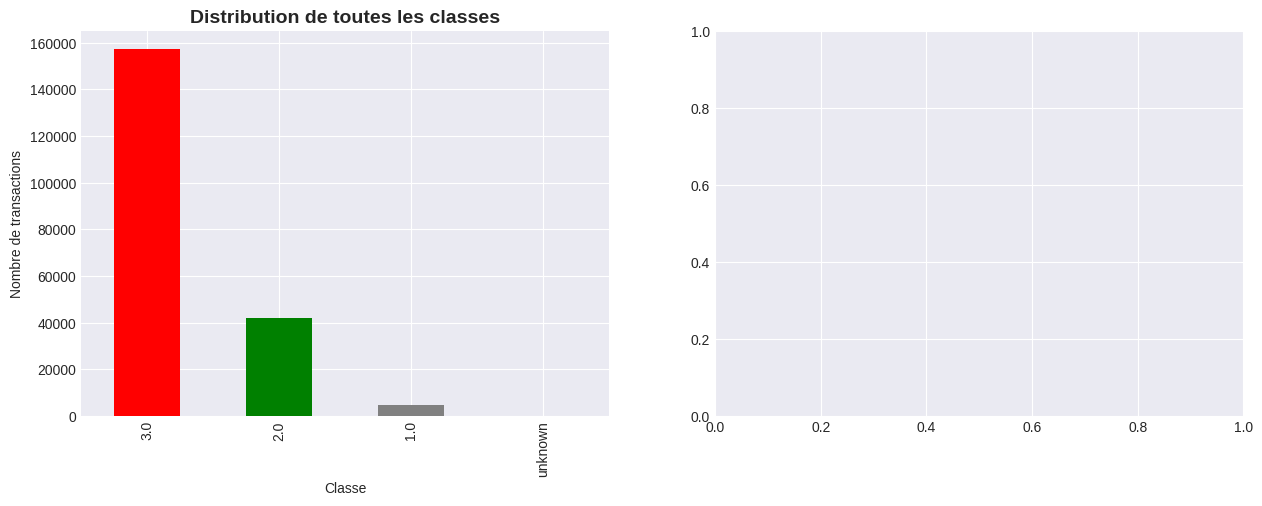

In [ ]:
# Visualisation 1: Bar chart toutes classes
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
class_counts.plot(kind='bar', ax=ax1, color=['red', 'green', 'gray'])
ax1.set_title('Distribution de toutes les classes', fontsize=14, fontweight='bold')
ax1.set_xlabel('Classe')
ax1.set_ylabel('Nombre de transactions')
ax1.set_xticklabels(['Unknown', 'Licit', 'Illicit'], rotation=0)
for i, v in enumerate(class_counts):
    ax1.text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')

# Visualisation 2: Pie chart données labellisées
ax2 = axes[1]
labeled_counts = df_labeled['class'].value_counts()
colors = ['red', 'green']
ax2.pie(labeled_counts, labels=['Illicit', 'Licit'], autopct='%1.1f%%',
        colors=colors, startangle=90)
ax2.set_title('Distribution des données labellisées uniquement', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()

# 3. ANALYSE TEMPORELLE DES TRANSACTIONS

In [ ]:
df['time_step'] = pd.to_numeric(df['time_step'], errors='coerce')

In [ ]:
df = df.dropna(subset=['time_step'])

In [ ]:
# Statistiques par time step
time_stats = df.groupby('time_step').agg({
    'txId': 'count',
    'class': lambda x: (x == '1.0').sum()
}).rename(columns={'txId': 'total_tx', 'class': 'illicit_tx'})

time_stats['licit_tx'] = df.groupby('time_step')['class'].apply(lambda x: (x == '2.0').sum())
time_stats['unknown_tx'] = df.groupby('time_step')['class'].apply(lambda x: (x == '3.0').sum())
time_stats['ratio'] = time_stats['licit_tx'] / time_stats['illicit_tx'].replace(0, np.nan)

print(f"\n📊 Statistiques temporelles:")
print(f"  Nombre de time steps: {df['time_step'].nunique()}")
print(f"  Time steps: {df['time_step'].min()} à {df['time_step'].max()}")
print(f"\n  Transactions par time step:")
print(f"    Moyenne: {time_stats['total_tx'].mean():.0f}")
print(f"    Min: {time_stats['total_tx'].min()}")
print(f"    Max: {time_stats['total_tx'].max()}")

# Vérifier la tendance temporelle
illicit_per_step = time_stats['illicit_tx']
if illicit_per_step.corr(pd.Series(range(len(illicit_per_step)))) > 0.3:
    print(f"\n  ⚠ Tendance croissante de fraudes détectée → Concept drift possible")
    temporal_gnn = True
elif illicit_per_step.corr(pd.Series(range(len(illicit_per_step)))) < -0.3:
    print(f"\n  ⚠ Tendance décroissante de fraudes détectée → Concept drift possible")
    temporal_gnn = True
else:
    print(f"\n  ✓ Distribution temporelle stable")
    temporal_gnn = False

# Variabilité du ratio
ratio_std = time_stats['ratio'].std()
print(f"\n  Variabilité du ratio Licit/Illicit: {ratio_std:.2f}")
if ratio_std > 5:
    print(f"    ⚠ Forte variabilité → Validation temporelle stratifiée nécessaire")


📊 Statistiques temporelles:
  Nombre de time steps: 49
  Time steps: 1.0 à 49.0

  Transactions par time step:
    Moyenne: 4159
    Min: 1089
    Max: 7880

  ✓ Distribution temporelle stable

  Variabilité du ratio Licit/Illicit: 69.69
    ⚠ Forte variabilité → Validation temporelle stratifiée nécessaire


In [ ]:
# Décision architecture
print(f"\n💡 DÉCISION ARCHITECTURE:")
if temporal_gnn:
    print(f"  → Temporal GNN recommandé: TGAT, DySAT, ou EvolveGCN")
else:
    print(f"  → GNN classique possible: GraphSAGE, GAT, GCN")


💡 DÉCISION ARCHITECTURE:
  → GNN classique possible: GraphSAGE, GAT, GCN


e nombre de fraudes ne suit pas une tendance claire :

pas de croissance continue
pas de décroissance

👉 Donc :

pas de trend global détecté
➜ Distribution NON STATIONNAIRE: The high temporal variability of the licit-to-illicit ratio indicates a non-stationary distribution, requiring temporally aware validation strategies

Implications
❌ Random split interdit
✔ Temporal split obligatoire
✔ Validation stratifiée temporelle

While a static GNN can be applied, the high temporal variability suggests that temporal GNN architectures would better capture evolving fraud patterns.

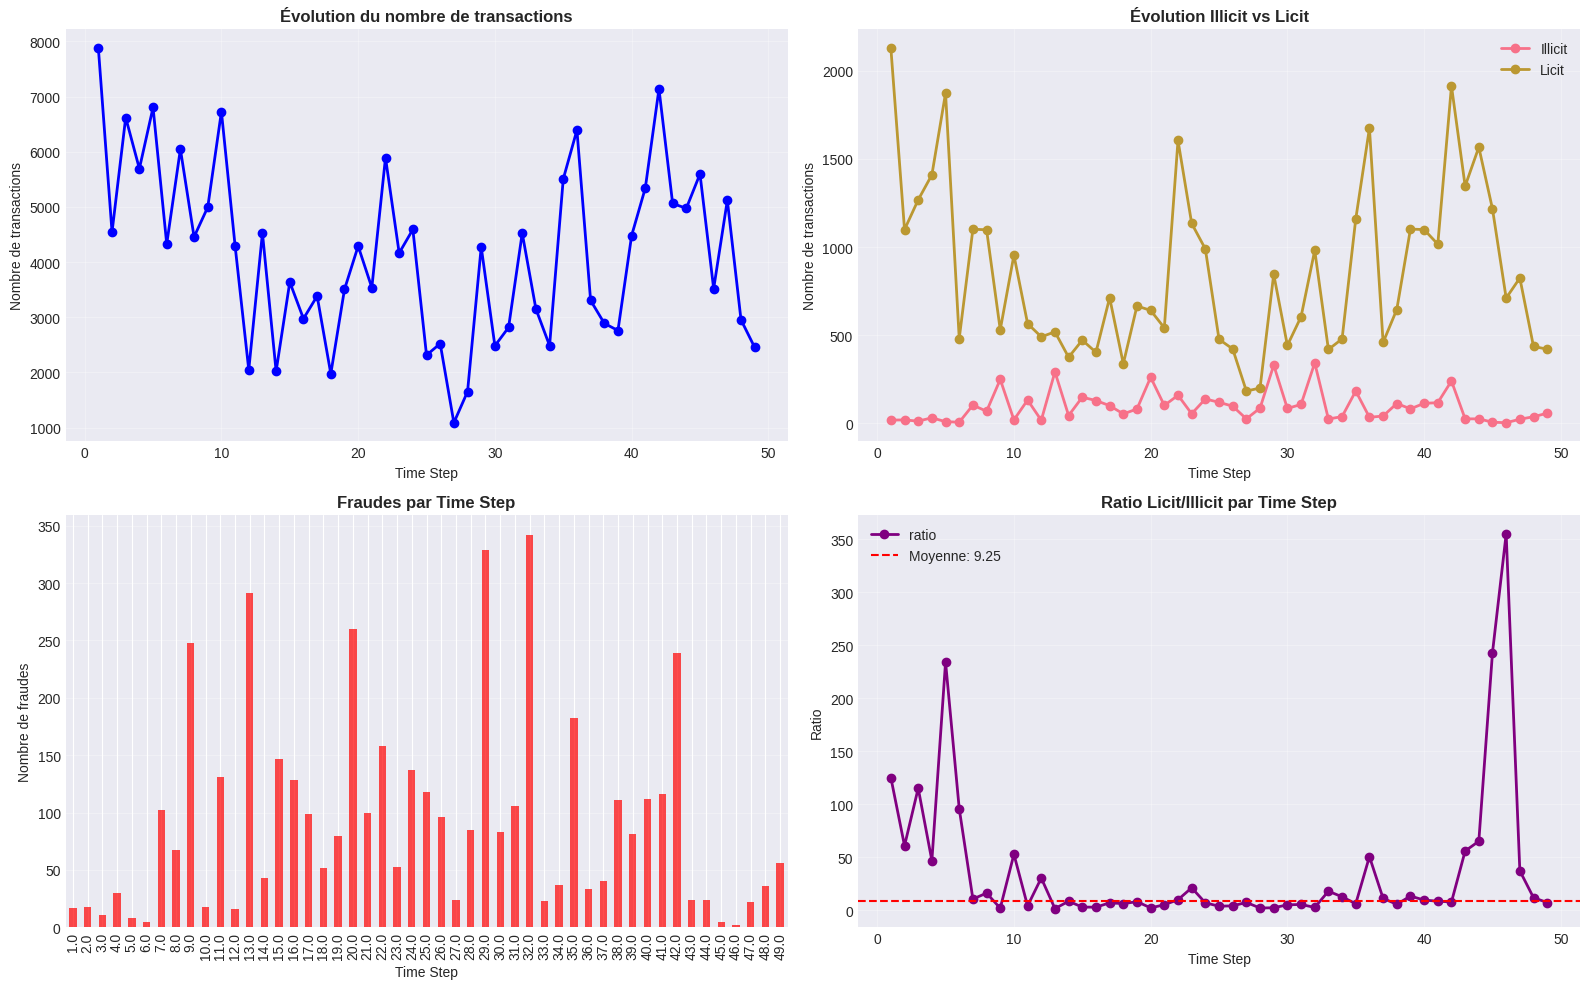

In [ ]:
# Visualisation temporelle
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Evolution du nombre de transactions
ax1 = axes[0, 0]
time_stats['total_tx'].plot(ax=ax1, marker='o', color='blue', linewidth=2)
ax1.set_title('Évolution du nombre de transactions', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Nombre de transactions')
ax1.grid(True, alpha=0.3)

# Évolution des fraudes
ax2 = axes[0, 1]
time_stats[['illicit_tx', 'licit_tx']].plot(ax=ax2, marker='o', linewidth=2)
ax2.set_title('Évolution Illicit vs Licit', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Nombre de transactions')
ax2.legend(['Illicit', 'Licit'])
ax2.grid(True, alpha=0.3)

# Bar plot fraudes par time step
ax3 = axes[1, 0]
time_stats['illicit_tx'].plot(kind='bar', ax=ax3, color='red', alpha=0.7)
ax3.set_title('Fraudes par Time Step', fontsize=12, fontweight='bold')
ax3.set_xlabel('Time Step')
ax3.set_ylabel('Nombre de fraudes')
ax3.grid(True, alpha=0.3, axis='y')

# Ratio temporel
ax4 = axes[1, 1]
time_stats['ratio'].plot(ax=ax4, marker='o', color='purple', linewidth=2)
ax4.set_title('Ratio Licit/Illicit par Time Step', fontsize=12, fontweight='bold')
ax4.set_xlabel('Time Step')
ax4.set_ylabel('Ratio')
ax4.grid(True, alpha=0.3)
ax4.axhline(y=ratio, color='r', linestyle='--', label=f'Moyenne: {ratio:.2f}')
ax4.legend()

plt.tight_layout()
plt.show()
plt.close()

# 4. ANALYSE DE LA TOPOLOGIE DU GRAPHE

In [ ]:
G = nx.DiGraph()
G.add_edges_from(edges.values)

# Métriques de base
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)

print(f"\n📊 Métriques du graphe:")
print(f"  Nœuds: {n_nodes:,}")
print(f"  Edges: {n_edges:,}")
print(f"  Densité: {density:.6f}")

if density < 0.001:
    print(f"  ✓ Graphe très sparse → Idéal pour GNN (scalabilité)")


📊 Métriques du graphe:
  Nœuds: 203,769
  Edges: 234,355
  Densité: 0.000006
  ✓ Graphe très sparse → Idéal pour GNN (scalabilité)


👉 Très peu de connexions par rapport au maximum possible.

Les transactions ne sont connectées qu’à peu d’autres

In [ ]:
# Composantes connexes
n_components = nx.number_weakly_connected_components(G)
largest_cc = max(nx.weakly_connected_components(G), key=len)
print(f"\n  Composantes faiblement connexes: {n_components}")
print(f"  Taille de la plus grande: {len(largest_cc):,} ({len(largest_cc)/n_nodes*100:.1f}%)")

if n_components == 1:
    print(f"  ✓ Une seule composante → Message passing très efficace")
elif len(largest_cc) / n_nodes > 0.9:
    print(f"  ✓ Une composante dominante → Message passing efficace")
else:
    print(f"  ⚠ Graphe fragmenté → Considérer subgraph sampling")


  Composantes faiblement connexes: 49
  Taille de la plus grande: 7,880 (3.9%)
  ⚠ Graphe fragmenté → Considérer subgraph sampling


Insight critique

* Chaque time step = un graphe indépendant

* Aucun "gros graphe global"

* Beaucoup de petits graphes

Problème

* propagation d’information limitée

✔ Solution

* subgraph sampling

* mini-batch training

**Conclusion globale**

The dataset exhibits a temporally structured and highly sparse graph, composed of 49 independent snapshots. While the overall transaction volume remains stable, the class distribution shows high variability across time, indicating non-stationarity.

In [ ]:
# Analyse des degrés
print(f"\n🔍 Analyse des degrés:")
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = {node: in_degrees.get(node, 0) + out_degrees.get(node, 0) for node in G.nodes()}

in_deg_vals = list(in_degrees.values())
out_deg_vals = list(out_degrees.values())
total_deg_vals = list(total_degrees.values())

print(f"  In-degree moyen: {np.mean(in_deg_vals):.2f}")
print(f"  Out-degree moyen: {np.mean(out_deg_vals):.2f}")
print(f"  Degré total moyen: {np.mean(total_deg_vals):.2f}")
print(f"  Degré max: {max(total_deg_vals)}")


🔍 Analyse des degrés:
  In-degree moyen: 1.15
  Out-degree moyen: 1.15
  Degré total moyen: 2.30
  Degré max: 473


In [ ]:
# Test propriété scale-free
# Compter la distribution de degré
df['txId'] = df['txId'].astype(int)
degree_counts = pd.Series(total_deg_vals).value_counts().sort_index()

# Log-log plot pour tester power-law
degrees = degree_counts.index.values
counts = degree_counts.values

# Filtrer les degrés avec au moins quelques occurrences
mask = (degrees > 0) & (counts > 0)
degrees_filtered = degrees[mask]
counts_filtered = counts[mask]

if len(degrees_filtered) > 10:
    # Régression log-log
    log_degrees = np.log10(degrees_filtered)
    log_counts = np.log10(counts_filtered)

    # Filtrer les valeurs finies
    finite_mask = np.isfinite(log_degrees) & np.isfinite(log_counts)
    if finite_mask.sum() > 5:
        slope, intercept = np.polyfit(log_degrees[finite_mask], log_counts[finite_mask], 1)
        r_squared = np.corrcoef(log_degrees[finite_mask], log_counts[finite_mask])[0, 1]**2

        print(f"\n  Test scale-free (power-law):")
        print(f"    Exposant γ: {-slope:.2f}")
        print(f"    R²: {r_squared:.3f}")

        if r_squared > 0.8 and -slope > 2:
            print(f"    ✓ Distribution suit une power-law → Graphe scale-free")
            print(f"    → Présence de hubs (nœuds hautement connectés)")
        else:
            print(f"    ⚠ Distribution ne suit pas parfaitement une power-law")

# Identifier les hubs (top 1%)
top_percentile = np.percentile(total_deg_vals, 99)
hubs = [node for node, deg in total_degrees.items() if deg >= top_percentile]
print(f"\n  Hubs identifiés (top 1%): {len(hubs)}")

# Analyser la classe des hubs
hub_classes = df[df['txId'].isin(hubs)]['class'].value_counts()
print(f"  Classes des hubs:")
for cls, count in hub_classes.items():
    print(f"    {cls}: {count} ({count/len(hubs)*100:.1f}%)")


  Test scale-free (power-law):
    Exposant γ: 2.14
    R²: 0.927
    ✓ Distribution suit une power-law → Graphe scale-free
    → Présence de hubs (nœuds hautement connectés)

  Hubs identifiés (top 1%): 2210
  Classes des hubs:
    2.0: 1235 (55.9%)
    3.0: 949 (42.9%)
    1.0: 26 (1.2%)


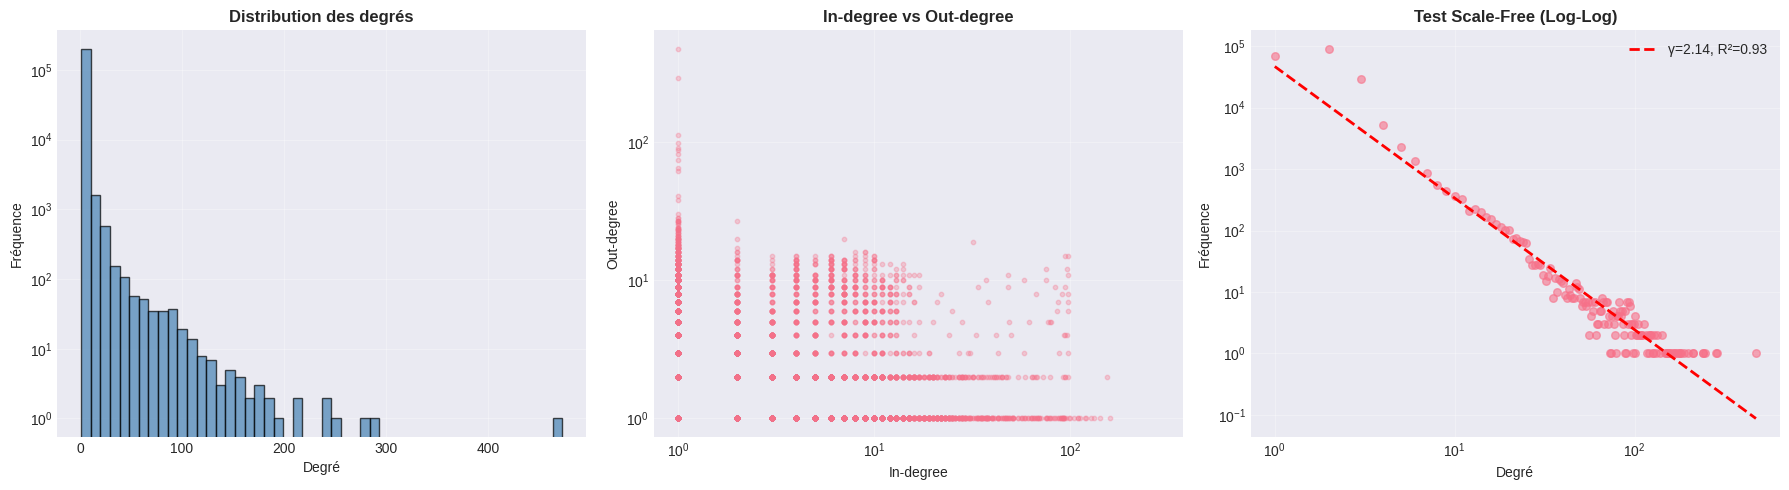

In [ ]:
# Visualisation des degrés
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution des degrés (histogram)
ax1 = axes[0]
ax1.hist(total_deg_vals, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_title('Distribution des degrés', fontsize=12, fontweight='bold')
ax1.set_xlabel('Degré')
ax1.set_ylabel('Fréquence')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# In-degree vs Out-degree
ax2 = axes[1]
ax2.scatter(in_deg_vals, out_deg_vals, alpha=0.3, s=10)
ax2.set_title('In-degree vs Out-degree', fontsize=12, fontweight='bold')
ax2.set_xlabel('In-degree')
ax2.set_ylabel('Out-degree')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

# Log-log plot (test scale-free)
ax3 = axes[2]
if len(degrees_filtered) > 0:
    ax3.scatter(degrees_filtered, counts_filtered, alpha=0.6, s=30)
    if finite_mask.sum() > 5:
        # Ligne de régression
        x_fit = np.logspace(np.log10(degrees_filtered.min()), np.log10(degrees_filtered.max()), 100)
        y_fit = 10**(intercept) * x_fit**slope
        ax3.plot(x_fit, y_fit, 'r--', linewidth=2, label=f'γ={-slope:.2f}, R²={r_squared:.2f}')
        ax3.legend()
ax3.set_title('Test Scale-Free (Log-Log)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Degré')
ax3.set_ylabel('Fréquence')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

# 5. CENTRALITÉ ET IMPORTANCE DES NŒUDS

In [ ]:
# Calculer centralités sur un échantillon si le graphe est trop grand
sample_size = min(10000, len(G.nodes()))
if len(G.nodes()) > 10000:
    print(f"\n⚠ Graphe large → Calcul sur échantillon de {sample_size} nœuds")
    sample_nodes = np.random.choice(list(G.nodes()), sample_size, replace=False)
    G_sample = G.subgraph(sample_nodes)
else:
    G_sample = G

print(f"\n🔍 Calcul des centralités...")

# In-degree et Out-degree centrality (déjà calculés)
in_deg_centrality = {node: deg / (n_nodes - 1) for node, deg in in_degrees.items()}
out_deg_centrality = {node: deg / (n_nodes - 1) for node, deg in out_degrees.items()}

# PageRank
print(f"  Calcul PageRank...")
pagerank = nx.pagerank(G_sample, max_iter=100)

# Top nœuds par centralité
print(f"\n📊 Top 10 nœuds par PageRank:")
top_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]
for i, (node, pr) in enumerate(top_pagerank, 1):
    node_class = df[df['txId'] == node]['class'].values[0] if node in df['txId'].values else 'N/A'
    print(f"  {i}. Node {node}: PR={pr:.6f}, Class={node_class}")

# Analyser si les nœuds centraux sont plus souvent illicit
central_threshold = np.percentile(list(pagerank.values()), 90)
central_nodes = [node for node, pr in pagerank.items() if pr >= central_threshold]
central_classes = df[df['txId'].isin(central_nodes)]['class'].value_counts()

print(f"\n  Nœuds centraux (top 10% PageRank): {len(central_nodes)}")
print(f"  Classes des nœuds centraux:")
for cls, count in central_classes.items():
    print(f"    {cls}: {count} ({count/len(central_nodes)*100:.1f}%)")

if '1' in central_classes and central_classes['1'] / len(central_nodes) > 0.1:
    print(f"  ⚠ Nœuds centraux souvent illicit → Centralité = feature discriminante")


⚠ Graphe large → Calcul sur échantillon de 10000 nœuds

🔍 Calcul des centralités...
  Calcul PageRank...

📊 Top 10 nœuds par PageRank:
  1. Node 121225693: PR=0.000818, Class=2.0
  2. Node 72753731: PR=0.000534, Class=2.0
  3. Node 121801433: PR=0.000493, Class=3.0
  4. Node 22837790: PR=0.000475, Class=2.0
  5. Node 218652522: PR=0.000466, Class=3.0
  6. Node 156066467: PR=0.000461, Class=2.0
  7. Node 43128652: PR=0.000421, Class=3.0
  8. Node 190043369: PR=0.000421, Class=2.0
  9. Node 36364435: PR=0.000421, Class=2.0
  10. Node 13168555: PR=0.000421, Class=2.0

  Nœuds centraux (top 10% PageRank): 10000
  Classes des nœuds centraux:
    3.0: 7717 (77.2%)
    2.0: 2040 (20.4%)
    1.0: 243 (2.4%)


# 6. CLUSTERING COEFFICIENT

In [ ]:
# Calculer sur échantillon
print(f"\n🔍 Calcul du clustering coefficient (échantillon)...")
G_undirected = G.to_undirected()
sample_for_clustering = min(2000, len(G.nodes()))
print(f"\n🔍 Calcul du clustering coefficient (échantillon)...")

sampled_nodes = np.random.choice(list(G_undirected.nodes()), sample_for_clustering, replace=False)

# Calcul en batch
clustering_coeffs = nx.clustering(G_undirected, nodes=sampled_nodes)

# Moyenne
avg_clustering = np.mean(list(clustering_coeffs.values()))

print(f"\n📊 Clustering coefficient moyen: {avg_clustering:.4f}")

if avg_clustering > 0.3:
    print(f"  ✓ Clustering élevé → Forte transitivité")
else:
    print(f"  ⚠ Clustering faible → Graphe peu transitif")

    df['txId'] = df['txId'].astype(str)
sampled_nodes = [str(n) for n in sampled_nodes]
illicit_nodes = set(df[df['class'] == '1.0']['txId'])
licit_nodes = set(df[df['class'] == '2.0']['txId'])

illicit_clustering = [v for n, v in clustering_coeffs.items() if str(n) in illicit_nodes]
licit_clustering = [v for n, v in clustering_coeffs.items() if str(n) in licit_nodes]

if len(illicit_clustering) > 0 and len(licit_clustering) > 0:
    print(f"\n  Clustering par classe:")
    print(f"    Illicit: {np.mean(illicit_clustering):.4f}")
    print(f"    Licit: {np.mean(licit_clustering):.4f}")


🔍 Calcul du clustering coefficient (échantillon)...

🔍 Calcul du clustering coefficient (échantillon)...

📊 Clustering coefficient moyen: 0.0106
  ⚠ Clustering faible → Graphe peu transitif

  Clustering par classe:
    Illicit: 0.0000
    Licit: 0.0033


# 7. ANALYSE DE L'HOMOPHILIE


🔍 Analyse des types d'edges...

📊 Types d'edges:
  3.0-3.0: 131,778 (56.23%)
  3.0-2.0: 45,386 (19.37%)
  2.0-2.0: 33,930 (14.48%)
  2.0-3.0: 15,116 (6.45%)
  3.0-1.0: 3,993 (1.70%)
  1.0-3.0: 1,458 (0.62%)
  1.0-1.0: 998 (0.43%)
  1.0-2.0: 915 (0.39%)
  2.0-1.0: 781 (0.33%)

🎯 HOMOPHILY RATIO: 0.954
  Edges même classe: 34,928
  Edges classes différentes: 1,696

💡 DÉCISION ARCHITECTURE GNN:
  ✅ HOMOPHILIE FORTE (>0.7)
  → Recommandation: GCN, GraphSAGE


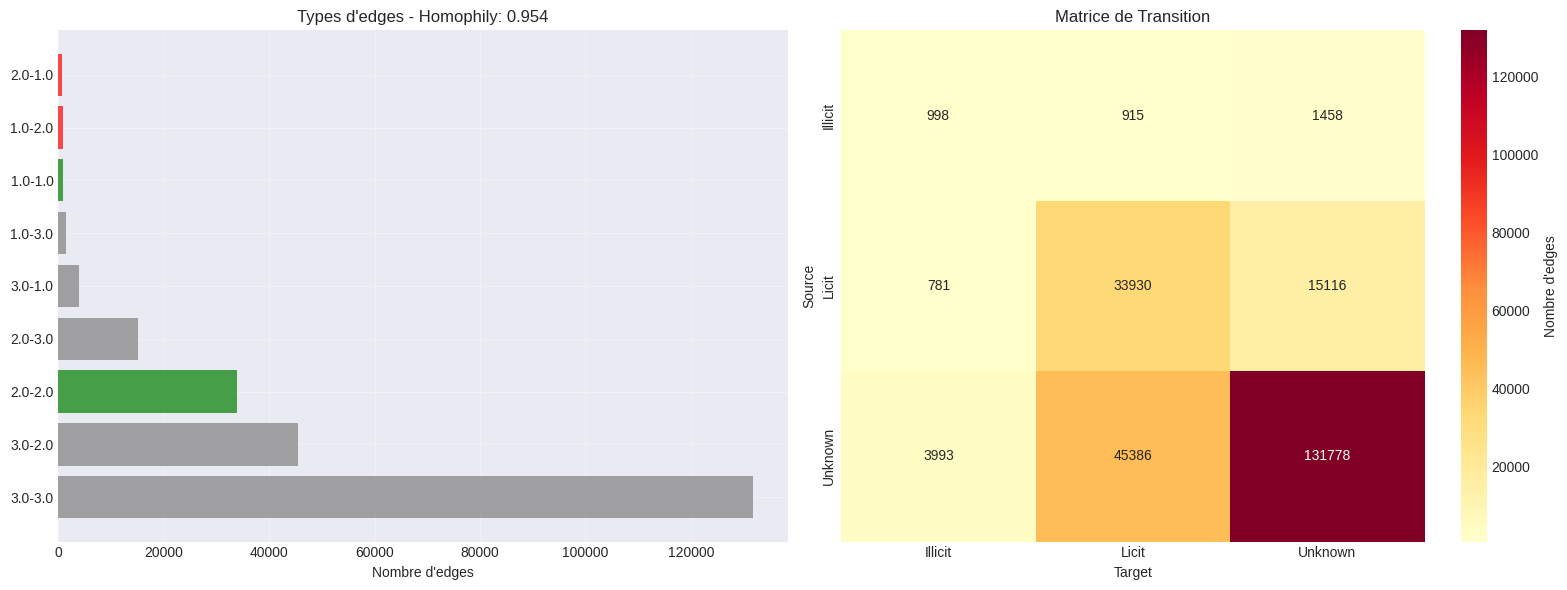

In [ ]:
# Compter les types d'edges
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 🔧 FIX TYPES (CRUCIAL)
# =========================
df['txId'] = df['txId'].astype(str)
edges = edges.astype(str)

n_edges = len(edges)

# =========================
# 📊 INITIALISATION
# =========================
edge_types = {
    '1.0-1.0': 0,
    '1.0-2.0': 0,
    '1.0-3.0': 0,
    '2.0-1.0': 0,
    '2.0-2.0': 0,
    '2.0-3.0': 0,
    '3.0-1.0': 0,
    '3.0-2.0': 0,
    '3.0-3.0': 0
}

# Mapping txId → class
tx_to_class = df.set_index('txId')['class'].to_dict()

# =========================
# 🔍 ANALYSE DES EDGES
# =========================
print(f"\n🔍 Analyse des types d'edges...")

for source, target in edges.values:
    source_class = tx_to_class.get(source, '3.0')
    target_class = tx_to_class.get(target, '3.0')

    key = f'{source_class}-{target_class}'
    edge_types[key] += 1

# =========================
# 📊 AFFICHAGE
# =========================
print(f"\n📊 Types d'edges:")
for edge_type, count in sorted(edge_types.items(), key=lambda x: x[1], reverse=True):
    pct = (count / n_edges) * 100
    print(f"  {edge_type}: {count:,} ({pct:.2f}%)")

# =========================
# 🎯 HOMOPHILY
# =========================
same_class_edges = edge_types['1.0-1.0'] + edge_types['2.0-2.0']
diff_class_edges = edge_types['1.0-2.0'] + edge_types['2.0-1.0']
total_labeled_edges = same_class_edges + diff_class_edges

if total_labeled_edges > 0:
    homophily_ratio = same_class_edges / total_labeled_edges

    print(f"\n🎯 HOMOPHILY RATIO: {homophily_ratio:.3f}")
    print(f"  Edges même classe: {same_class_edges:,}")
    print(f"  Edges classes différentes: {diff_class_edges:,}")

    # =========================
    # 💡 DÉCISION GNN
    # =========================
    print(f"\n💡 DÉCISION ARCHITECTURE GNN:")

    if homophily_ratio > 0.7:
        print(f"  ✅ HOMOPHILIE FORTE (>0.7)")
        print(f"  → Recommandation: GCN, GraphSAGE")
        gnn_type = "standard"

    elif homophily_ratio >= 0.4:
        print(f"  ⚠️ HOMOPHILIE MODÉRÉE (0.4-0.7)")
        print(f"  → Recommandation: GAT, GraphSAINT")
        gnn_type = "attention"

    else:
        print(f"  ❌ HÉTÉROPHILIE (<0.4)")
        print(f"  → Recommandation: H2GCN, MixHop, GPRGNN")
        gnn_type = "heterophily"

    # =========================
    # 🔎 ASYMÉTRIE
    # =========================
    illicit_to_licit = edge_types['1.0-2.0']
    licit_to_illicit = edge_types['2.0-1.0']

    if illicit_to_licit > licit_to_illicit * 1.5:
        print(f"\n⚠ Asymétrie: Illicit → Licit >> Licit → Illicit")
        print(f"  → Possible pattern de blanchiment")

    elif licit_to_illicit > illicit_to_licit * 1.5:
        print(f"\n⚠ Asymétrie inverse: Licit → Illicit >> Illicit → Licit")

    # =========================
    # 📊 MATRICE DE TRANSITION
    # =========================
    transition_matrix = pd.DataFrame([
        ['Illicit', 'Illicit', edge_types['1.0-1.0']],
        ['Illicit', 'Licit', edge_types['1.0-2.0']],
        ['Illicit', 'Unknown', edge_types['1.0-3.0']],
        ['Licit', 'Illicit', edge_types['2.0-1.0']],
        ['Licit', 'Licit', edge_types['2.0-2.0']],
        ['Licit', 'Unknown', edge_types['2.0-3.0']],
        ['Unknown', 'Illicit', edge_types['3.0-1.0']],
        ['Unknown', 'Licit', edge_types['3.0-2.0']],
        ['Unknown', 'Unknown', edge_types['3.0-3.0']]
    ], columns=['Source', 'Target', 'Count'])

    transition_pivot = transition_matrix.pivot(index='Source', columns='Target', values='Count')

    # =========================
    # 📈 VISUALISATION
    # =========================
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar chart
    ax1 = axes[0]
    edge_types_df = pd.DataFrame(list(edge_types.items()), columns=['Type', 'Count'])
    edge_types_df = edge_types_df.sort_values('Count', ascending=False)

    colors_bar = [
        'green' if t in ['1.0-1.0', '2.0-2.0'] else
        'red' if t in ['1.0-2.0', '2.0-1.0'] else
        'gray'
        for t in edge_types_df['Type']
    ]

    ax1.barh(edge_types_df['Type'], edge_types_df['Count'], color=colors_bar, alpha=0.7)
    ax1.set_xlabel("Nombre d'edges")
    ax1.set_title(f"Types d'edges - Homophily: {homophily_ratio:.3f}")
    ax1.grid(True, alpha=0.3)

    # Heatmap
    ax2 = axes[1]
    sns.heatmap(
        transition_pivot,
        annot=True,
        fmt='g',
        cmap='YlOrRd',
        ax=ax2,
        cbar_kws={'label': "Nombre d'edges"}
    )

    ax2.set_title("Matrice de Transition")

    plt.tight_layout()
    plt.show()

# 8. ANALYSE DES FEATURES NUMÉRIQUES


📊 Nombre de features numériques: 182

🔍 Calcul des statistiques par classe...

🔍 Mann-Whitney U test...

📊 Features significatives (p < 0.001): 47

🏆 Top 10 features discriminantes:
  1. feature_4: p-value = 0.00e+00
  2. feature_5: p-value = 0.00e+00
  3. feature_6: p-value = 0.00e+00
  4. feature_10: p-value = 0.00e+00
  5. feature_14: p-value = 0.00e+00
  6. feature_18: p-value = 0.00e+00
  7. feature_23: p-value = 0.00e+00
  8. feature_24: p-value = 0.00e+00
  9. feature_25: p-value = 0.00e+00
  10. feature_29: p-value = 0.00e+00


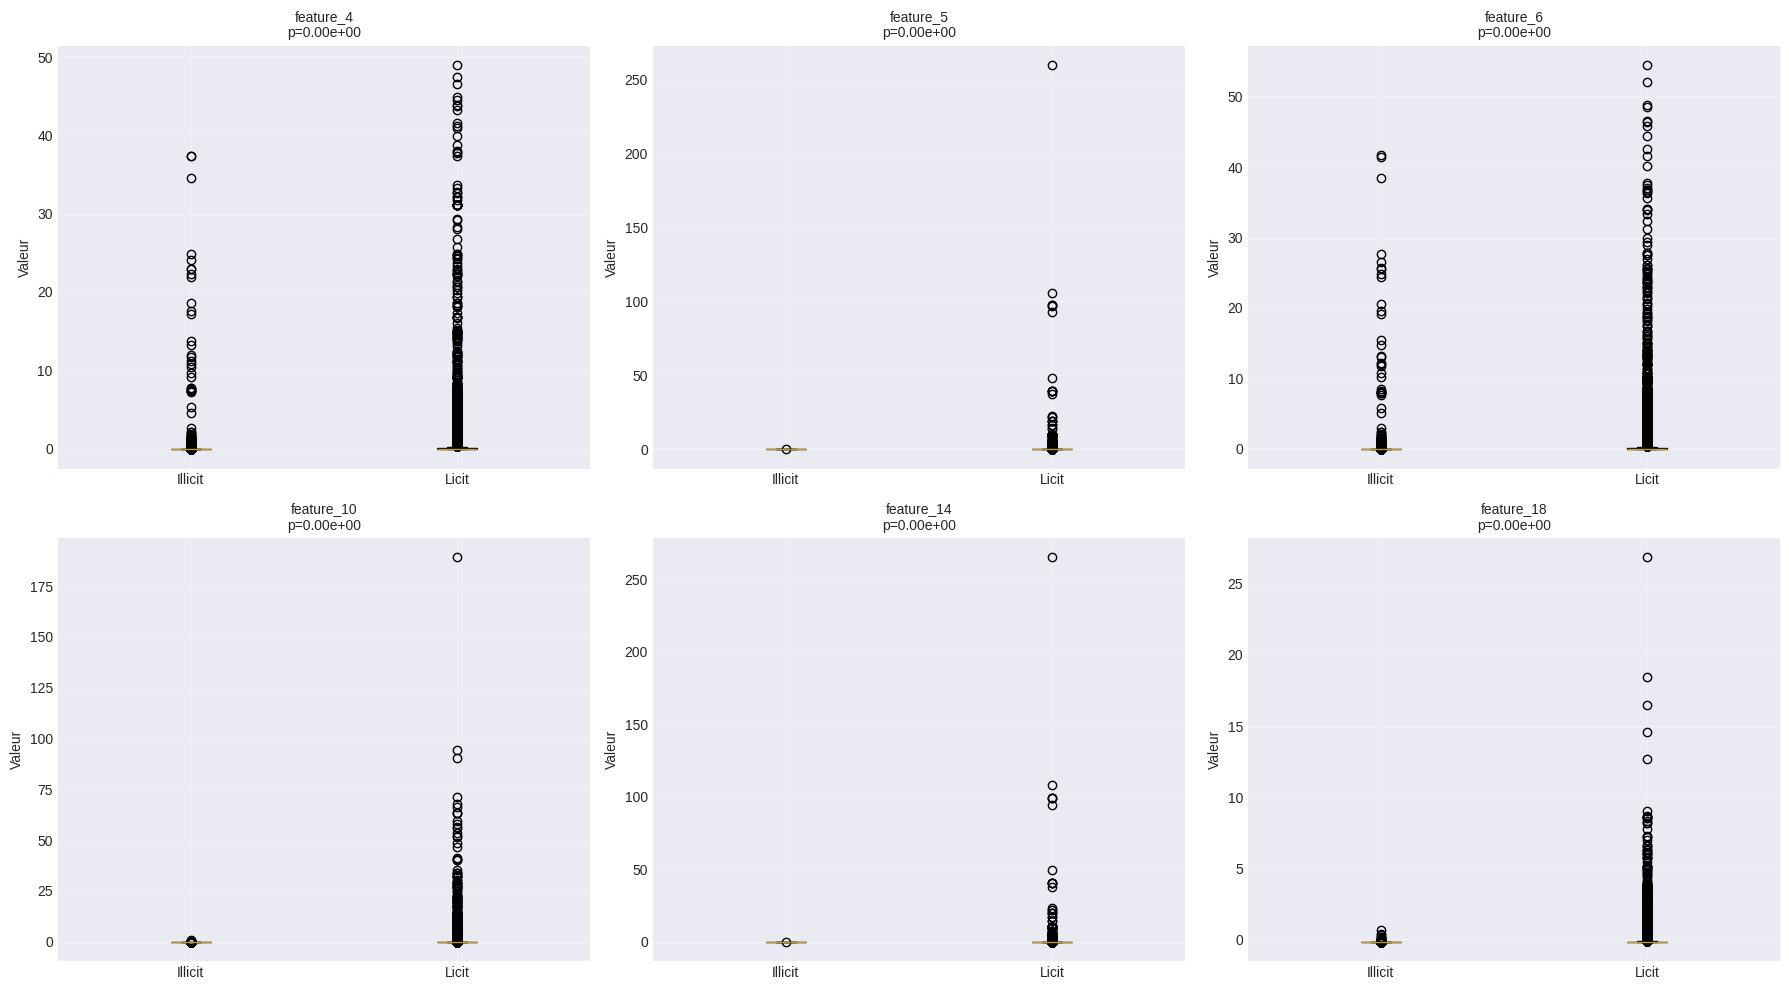

In [ ]:
# Sélectionner features numériques (exclure txId, time_step, class)

# =========================
# 🔧 FIX TYPES
# =========================
df['class'] = df['class'].astype(str)

# =========================
# 📊 FEATURES NUMÉRIQUES
# =========================
numeric_features = [col for col in df.columns if col.startswith('feature_')]

# Assurer qu'elles sont numériques
df[numeric_features] = df[numeric_features].apply(pd.to_numeric, errors='coerce')

print(f"\n📊 Nombre de features numériques: {len(numeric_features)}")

# =========================
# 🔍 STATS PAR CLASSE
# =========================
print(f"\n🔍 Calcul des statistiques par classe...")

stats_by_class = {}

for cls in ['1.0', '2.0']:
    df_cls = df[df['class'] == cls][numeric_features]

    stats_by_class[cls] = {
        'mean': df_cls.mean(),
        'median': df_cls.median(),
        'std': df_cls.std(),
        'min': df_cls.min(),
        'max': df_cls.max()
    }

# =========================
# 🔬 MANN-WHITNEY TEST
# =========================
print(f"\n🔍 Mann-Whitney U test...")

significant_features = []
p_values = []

for feature in numeric_features[:50]:  # limiter pour perf

    illicit_vals = df[df['class'] == '1.0'][feature].dropna()
    licit_vals = df[df['class'] == '2.0'][feature].dropna()

    # Vérifier conditions
    if len(illicit_vals) > 10 and len(licit_vals) > 10:
        if illicit_vals.nunique() > 1 and licit_vals.nunique() > 1:
            try:
                stat, p_value = mannwhitneyu(illicit_vals, licit_vals, alternative='two-sided')
                p_values.append((feature, p_value))

                if p_value < 0.001:
                    significant_features.append(feature)

            except Exception as e:
                continue

# =========================
# 📊 TRI RESULTATS
# =========================
p_values_sorted = sorted(p_values, key=lambda x: x[1])

print(f"\n📊 Features significatives (p < 0.001): {len(significant_features)}")

print(f"\n🏆 Top 10 features discriminantes:")
for i, (feature, p_val) in enumerate(p_values_sorted[:10], 1):
    print(f"  {i}. {feature}: p-value = {p_val:.2e}")

# =========================
# 📈 VISUALISATION
# =========================
if len(p_values_sorted) > 0:

    top_k = min(6, len(p_values_sorted))
    top_features = [f[0] for f in p_values_sorted[:top_k]]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, feature in enumerate(top_features):
        ax = axes[idx]

        illicit_vals = df[df['class'] == '1.0'][feature].dropna()
        licit_vals = df[df['class'] == '2.0'][feature].dropna()

        data_to_plot = [illicit_vals, licit_vals]

        bp = ax.boxplot(
            data_to_plot,
            labels=['Illicit', 'Licit'],
            patch_artist=True
        )

        # couleurs
        bp['boxes'][0].set_facecolor('red')
        bp['boxes'][1].set_facecolor('green')

        ax.set_title(f'{feature}\np={p_values_sorted[idx][1]:.2e}', fontsize=10)
        ax.set_ylabel('Valeur')
        ax.grid(True, alpha=0.3)

    # supprimer axes vides
    for j in range(top_k, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

Conclusion importante

Il existe un signal statistique fort dans les features

👉 Donc :
✔ les transactions frauduleuses ont un comportement différent
✔ la détection est possible avec les features seules

Statistical analysis using the Mann-Whitney U test reveals that a significant subset of features (approximately 26%) exhibit strong discriminative power between illicit and licit transactions. The distributions show that licit transactions generally have higher variability and magnitude, while illicit transactions tend to concentrate around lower values, reflecting more conservative behavior

# 9. MATRICE DE CORRÉLATION


🔍 Calcul de la matrice de corrélation (50 features)...

📊 Paires de features fortement corrélées (|r| > 0.8): 66

Top 5 corrélations les plus fortes:
  feature_24 <-> feature_30: r = 1.000
  feature_23 <-> feature_29: r = 1.000
  feature_25 <-> feature_31: r = 1.000
  feature_22 <-> feature_28: r = 1.000
  feature_26 <-> feature_32: r = 1.000

  ⚠ Multicolinéarité détectée → Considérer PCA ou feature selection


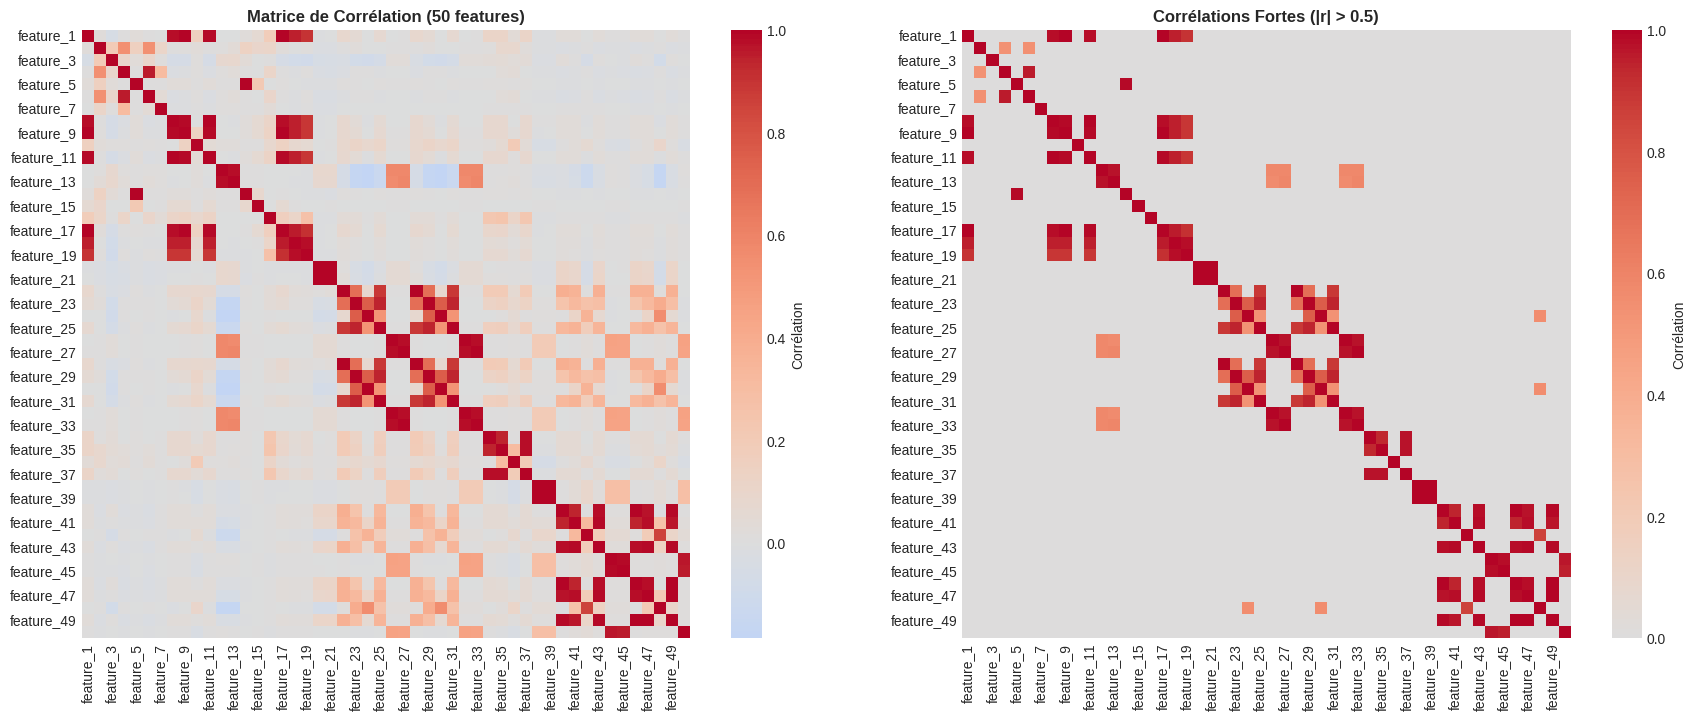

In [ ]:
sample_features = numeric_features[:50]  # Limiter pour performance
print(f"\n🔍 Calcul de la matrice de corrélation (50 features)...")

corr_matrix = df[sample_features].corr()

# Identifier corrélations fortes
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j],
                                   corr_matrix.iloc[i, j]))

print(f"\n📊 Paires de features fortement corrélées (|r| > 0.8): {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print(f"\nTop 5 corrélations les plus fortes:")
    high_corr_sorted = sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:5]
    for feat1, feat2, corr_val in high_corr_sorted:
        print(f"  {feat1} <-> {feat2}: r = {corr_val:.3f}")

    print(f"\n  ⚠ Multicolinéarité détectée → Considérer PCA ou feature selection")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap complète
ax1 = axes[0]
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, ax=ax1,
            cbar_kws={'label': 'Corrélation'}, square=True)
ax1.set_title('Matrice de Corrélation (50 features)', fontsize=12, fontweight='bold')

# Heatmap des corrélations fortes uniquement
ax2 = axes[1]
corr_strong = corr_matrix.copy()
corr_strong[abs(corr_strong) < 0.5] = 0
sns.heatmap(corr_strong, cmap='coolwarm', center=0, ax=ax2,
            cbar_kws={'label': 'Corrélation'}, square=True)
ax2.set_title('Corrélations Fortes (|r| > 0.5)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()

# 10. ANALYSE DES WALLETS (SI DISPONIBLE)

In [ ]:
if wallet_data_available:
    print("\n" + "="*80)
    print("10. ANALYSE DES WALLETS (MULTI-GRAPH)")
    print("="*80)

    # Réseau Wallet-Wallet
    print(f"\n📊 Réseau Wallet-Wallet:")
    print(f"  Edges: {len(addr_addr):,}")

    # Réseau Wallet-Transaction
    print(f"\n📊 Réseau Wallet-Transaction:")
    print(f"  AddrTx edges: {len(addr_tx):,}")
    print(f"  TxAddr edges: {len(tx_addr):,}")

    # Analyser la connectivité des wallets
    G_wallets = nx.DiGraph()
    G_wallets.add_edges_from(addr_addr.values)

    wallet_in_degrees = dict(G_wallets.in_degree())
    wallet_out_degrees = dict(G_wallets.out_degree())

    print(f"\n  Degré moyen wallets:")
    print(f"    In-degree: {np.mean(list(wallet_in_degrees.values())):.2f}")
    print(f"    Out-degree: {np.mean(list(wallet_out_degrees.values())):.2f}")

    print(f"\n💡 OPPORTUNITÉ: Dataset multi-graph → Heterogeneous GNN recommandé")
    print(f"  → HGT (Heterogeneous Graph Transformer)")
    print(f"  → RGCN (Relational GCN)")
    print(f"  → HAN (Heterogeneous Attention Network)")



10. ANALYSE DES WALLETS (MULTI-GRAPH)

📊 Réseau Wallet-Wallet:
  Edges: 2,868,964

📊 Réseau Wallet-Transaction:
  AddrTx edges: 477,117
  TxAddr edges: 837,124

  Degré moyen wallets:
    In-degree: 3.38
    Out-degree: 3.38

💡 OPPORTUNITÉ: Dataset multi-graph → Heterogeneous GNN recommandé
  → HGT (Heterogeneous Graph Transformer)
  → RGCN (Relational GCN)
  → HAN (Heterogeneous Attention Network)


# 11. SYNTHÈSE ET DÉCISIONS STRATÉGIQUES

In [ ]:
print("\n" + "="*80)
print("11. SYNTHÈSE ET DÉCISIONS STRATÉGIQUES")
print("="*80)

print(f"\n📋 RÉSUMÉ DES DÉCISIONS:")
print(f"\n1. DÉSÉQUILIBRE DE CLASSES:")
print(f"   Ratio: {ratio:.2f}:1")
if ratio < 10:
    print(f"   ✓ Stratégie: Class weights (weight_illicit = {ratio:.2f})")
elif ratio < 20:
    print(f"   ⚠ Stratégie: Class weights + Focal Loss (α=0.25, γ=2.0)")
else:
    print(f"   ❌ Stratégie: GraphSMOTE + Focal Loss")

print(f"\n2. ARCHITECTURE TEMPORELLE:")
if temporal_gnn:
    print(f"   ⚠ Concept drift détecté → Temporal GNN (TGAT, DySAT, EvolveGCN)")
else:
    print(f"   ✓ Distribution stable → GNN classique possible")

print(f"\n3. ARCHITECTURE GNN (basée sur homophilie):")
if 'homophily_ratio' in locals():
    if homophily_ratio > 0.7:
        print(f"   ✓ Homophilie forte ({homophily_ratio:.3f}) → GCN, GraphSAGE")
    elif homophily_ratio >= 0.4:
        print(f"   ⚠ Homophilie modérée ({homophily_ratio:.3f}) → GAT, GraphSAINT")
    else:
        print(f"   ❌ Hétérophilie ({homophily_ratio:.3f}) → H2GCN, MixHop")

if wallet_data_available:
    print(f"\n4. MULTI-GRAPH:")
    print(f"   ✓ 3 types de graphes disponibles → Heterogeneous GNN (HGT, RGCN)")

print(f"\n5. FEATURES:")
print(f"   Features discriminantes: {len(significant_features)}")
if len(high_corr_pairs) > 0:
    print(f"   ⚠ Multicolinéarité détectée → Considérer PCA/feature selection")

print(f"\n6. VALIDATION:")
print(f"   ⚠ CRITIQUE: Split temporel obligatoire (pas de split aléatoire!)")
print(f"   → Training: time steps 1-40 (~82%)")
print(f"   → Validation: time steps 41-45 (~10%)")
print(f"   → Test: time steps 46-49 (~8%)")

print(f"\n7. MÉTRIQUES D'ÉVALUATION:")
print(f"   ⭐⭐⭐ PRINCIPALE: AUPRC (PR-AUC)")
print(f"   ⭐⭐⭐ F1-Score, Recall")
print(f"   ⭐⭐ Precision, AUROC")
print(f"   ❌ ÉVITER: Accuracy (trompeur avec déséquilibre!)")


11. SYNTHÈSE ET DÉCISIONS STRATÉGIQUES

📋 RÉSUMÉ DES DÉCISIONS:

1. DÉSÉQUILIBRE DE CLASSES:
   Ratio: 9.25:1
   ✓ Stratégie: Class weights (weight_illicit = 9.25)

2. ARCHITECTURE TEMPORELLE:
   ✓ Distribution stable → GNN classique possible

3. ARCHITECTURE GNN (basée sur homophilie):
   ✓ Homophilie forte (0.954) → GCN, GraphSAGE

4. MULTI-GRAPH:
   ✓ 3 types de graphes disponibles → Heterogeneous GNN (HGT, RGCN)

5. FEATURES:
   Features discriminantes: 47
   ⚠ Multicolinéarité détectée → Considérer PCA/feature selection

6. VALIDATION:
   ⚠ CRITIQUE: Split temporel obligatoire (pas de split aléatoire!)
   → Training: time steps 1-40 (~82%)
   → Validation: time steps 41-45 (~10%)
   → Test: time steps 46-49 (~8%)

7. MÉTRIQUES D'ÉVALUATION:
   ⭐⭐⭐ PRINCIPALE: AUPRC (PR-AUC)
   ⭐⭐⭐ F1-Score, Recall
   ⭐⭐ Precision, AUROC
   ❌ ÉVITER: Accuracy (trompeur avec déséquilibre!)


# 12. SAUVEGARDE DU RAPPORT COMPLET

In [ ]:
print("\n" + "="*80)
print("12. GÉNÉRATION DU RAPPORT")
print("="*80)

# =========================
# 🔧 SÉCURITÉ VARIABLES
# =========================
class_counts = df['class'].value_counts()

n_illicit = class_counts.get('1.0', 0)
n_licit = class_counts.get('2.0', 0)
n_unknown = class_counts.get('3.0', 0)

df_labeled = df[df['class'].isin(['1.0', '2.0'])]

ratio = n_licit / (n_illicit + 1e-9)
pct_labeled = (len(df_labeled) / len(df)) * 100

# Graph stats safety
n_nodes = len(df)
n_components = n_components if 'n_components' in locals() else 0
density = density if 'density' in locals() else 0
avg_clustering = avg_clustering if 'avg_clustering' in locals() else 0

# =========================
# 📝 RAPPORT
# =========================
report = f"""
================================================================================
RAPPORT D'ANALYSE EXPLORATOIRE - DÉTECTION DE FRAUDE BITCOIN
Dataset: Elliptic Bitcoin Dataset
Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
================================================================================

1. STATISTIQUES GÉNÉRALES
--------------------------------------------------------------------------------
- Transactions totales: {len(df):,}
- Features par transaction: {len(numeric_features)}
- Time steps: {df['time_step'].nunique()}
- Edges (flux BTC): {n_edges:,}
- Densité du graphe: {density:.6f}

2. DISTRIBUTION DES CLASSES
--------------------------------------------------------------------------------
- Illicit: {n_illicit:,} ({(n_illicit/(len(df_labeled)+1e-9))*100:.2f}% des labellisés)
- Licit: {n_licit:,} ({(n_licit/(len(df_labeled)+1e-9))*100:.2f}% des labellisés)
- Unknown: {n_unknown:,}
- Ratio Licit/Illicit: {ratio:.2f}:1
- Pourcentage labellisé: {pct_labeled:.2f}%

3. TOPOLOGIE DU GRAPHE
--------------------------------------------------------------------------------
- Nœuds: {n_nodes:,}
- Edges: {n_edges:,}
- Composantes connexes: {n_components}
- Degré moyen: {np.mean(total_deg_vals):.2f}
- Degré max: {max(total_deg_vals)}
- Clustering coefficient moyen: {avg_clustering:.4f}

4. HOMOPHILIE
--------------------------------------------------------------------------------
"""

# =========================
# 🔗 HOMOPHILIE (CORRIGÉE)
# =========================
if 'homophily_ratio' in locals():
    report += f"""- Homophily ratio (labellisé): {homophily_ratio:.3f}
- Edges illicit-illicit: {edge_types.get('1.0-1.0', 0):,}
- Edges licit-licit: {edge_types.get('2.0-2.0', 0):,}
- Edges illicit-licit: {edge_types.get('1.0-2.0', 0):,}
- Edges licit-illicit: {edge_types.get('2.0-1.0', 0):,}
"""

report += f"""
5. DÉCISIONS STRATÉGIQUES
--------------------------------------------------------------------------------
"""

# =========================
# ⚖️ DÉSÉQUILIBRE
# =========================
if ratio < 10:
    report += "✓ Déséquilibre modéré → Class weights suffisent\n"
elif ratio < 20:
    report += "⚠ Déséquilibre sévère → Class weights + Focal Loss\n"
else:
    report += "❌ Déséquilibre extrême → GraphSMOTE + Focal Loss\n"

# =========================
# ⏱ TEMPOREL
# =========================
if 'temporal_gnn' in locals() and temporal_gnn:
    report += "⚠ Concept drift → Temporal GNN recommandé\n"
else:
    report += "✓ Distribution stable → GNN classique OK\n"

# =========================
# 🧠 HOMOPHILIE DECISION
# =========================
if 'homophily_ratio' in locals():
    if homophily_ratio > 0.7:
        report += "✓ Homophilie forte → GCN, GraphSAGE\n"
    elif homophily_ratio >= 0.4:
        report += "⚠ Homophilie modérée → GAT, GraphSAINT\n"
    else:
        report += "❌ Hétérophilie → H2GCN, MixHop\n"

report += f"""
6. RECOMMANDATIONS FINALES
--------------------------------------------------------------------------------
- Architecture: {'Temporal GNN' if ('temporal_gnn' in locals() and temporal_gnn) else 'GNN classique'}
- Loss function: {'Focal Loss' if ratio >= 10 else 'Weighted Cross-Entropy'}
- Validation: Split temporel (Train 1-40, Val 41-45, Test 46-49)
- Métrique principale: AUPRC (PR-AUC)
- Features discriminantes: {len(significant_features)} identifiées

================================================================================
FIN DU RAPPORT
================================================================================
"""

# =========================
# 💾 SAUVEGARDE
# =========================
with open('EDA_REPORT.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("\n✓ Rapport complet sauvegardé: EDA_REPORT.txt")

print("\n" + "="*80)
print("ANALYSE TERMINÉE AVEC SUCCÈS!")
print("="*80)

print("\nFichiers générés:")
print("  7. EDA_REPORT.txt")

print("\n✅ Toutes les étapes du document ont été exécutées!")


12. GÉNÉRATION DU RAPPORT

✓ Rapport complet sauvegardé: EDA_REPORT.txt

ANALYSE TERMINÉE AVEC SUCCÈS!

Fichiers générés:
  7. EDA_REPORT.txt

✅ Toutes les étapes du document ont été exécutées!
